# Monitoria: do CLP ao celular

**Monitoria de Introdução às Redes de Comunicação, UFPE · 2026.2 · 5 horas**

Hoje cada grupo constrói, do zero até o celular, um sistema que monitora e comanda a bancada:

- o **CLP** mede a temperatura e aciona o motor pelo inversor;
- um **gateway** em Python lê o CLP por Modbus TCP e publica os dados num **broker MQTT**;
- um **middleware** em Python grava tudo num banco e serve um **app** que abre no celular;
- pelo celular, o operador comanda o motor, e o comando faz o caminho inverso até o CLP.

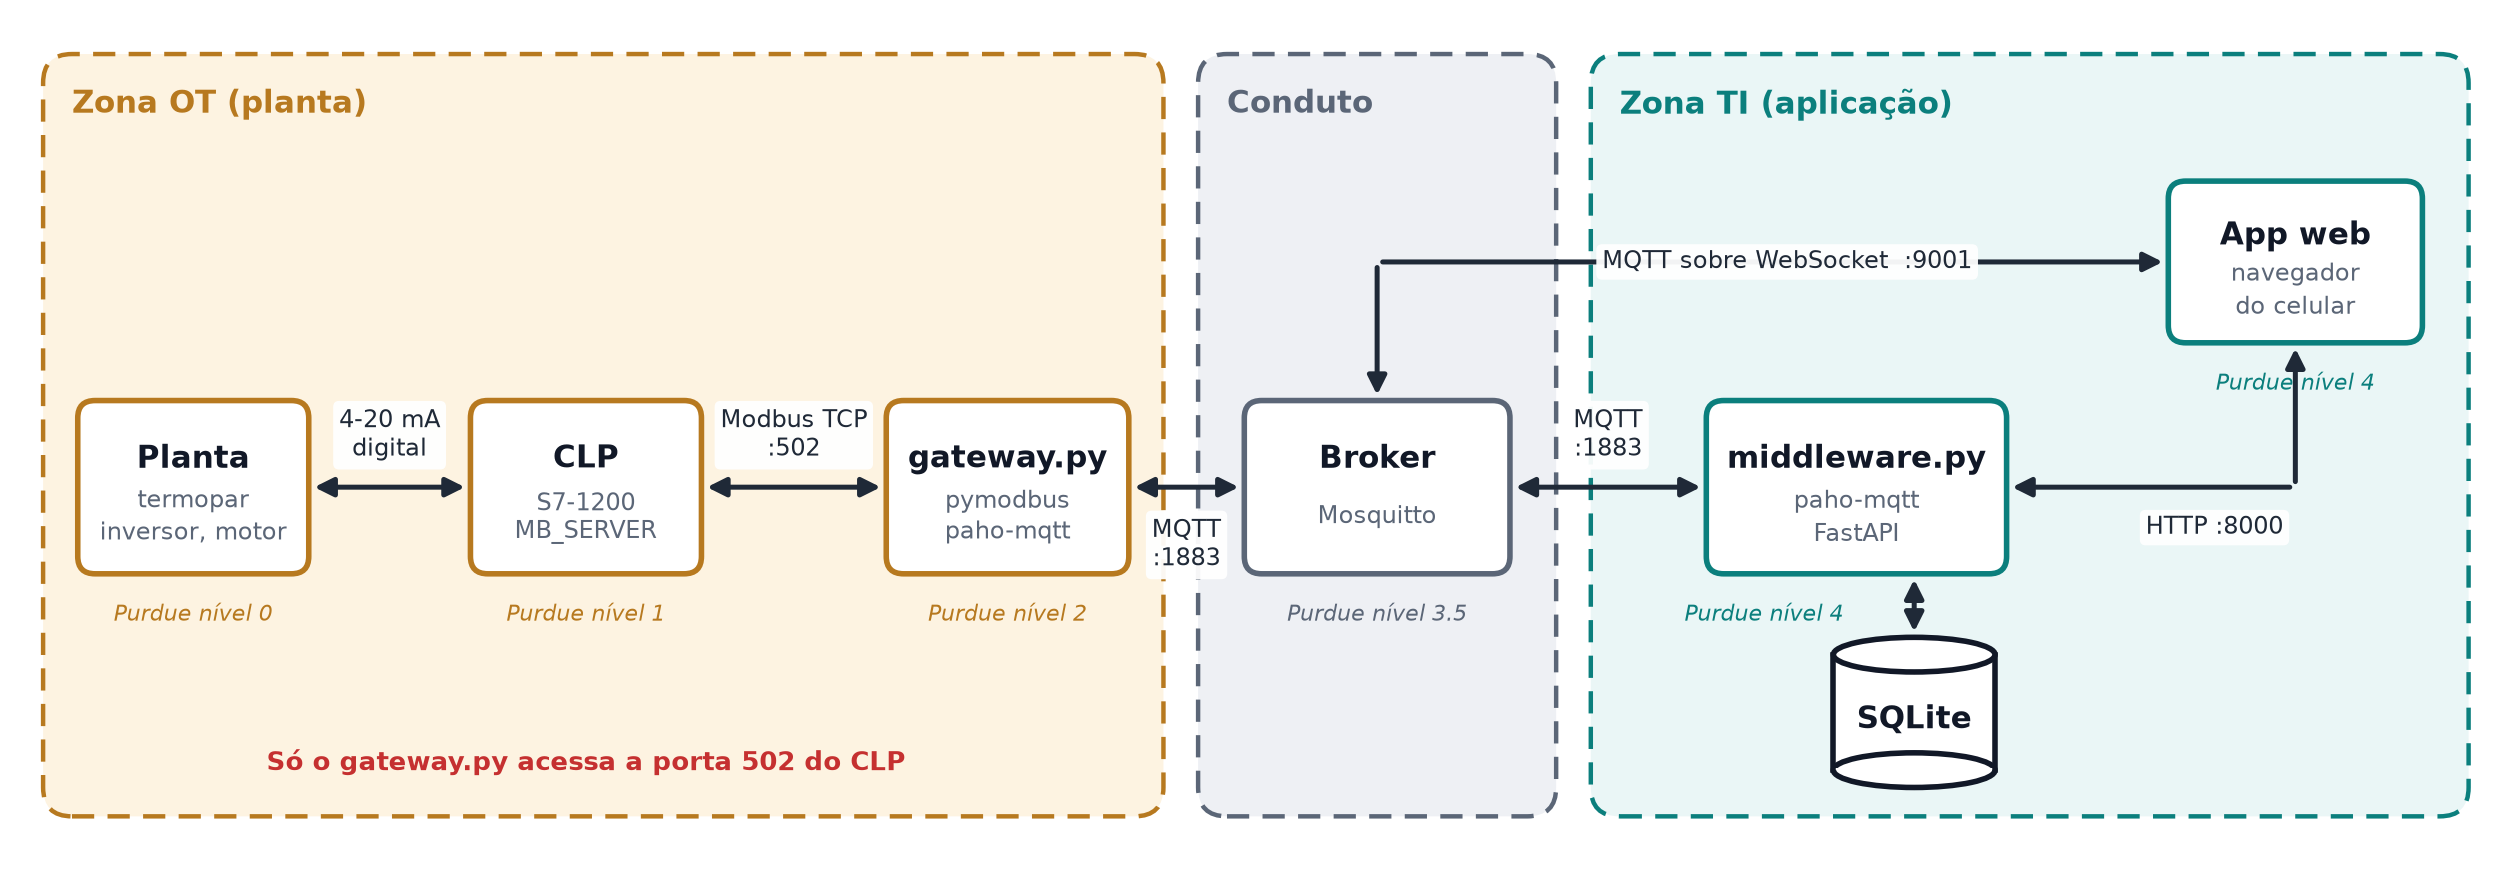

Cada grupo é uma **bancada** (`bancada1`, `bancada2`, ...), com o seu CLP, e levanta o **próprio broker MQTT** no notebook do grupo. O primeiro nível de todos os tópicos é o nome da bancada.

Referências no projeto: `Arquitetura.md` (a arquitetura) e `decisoes/` (as 30 decisões de projeto, com o porquê de cada uma).

## Cronograma

| Horário | Etapa | Ao final você deve ver |
|---|---|---|
| 0:00 a 0:15 | Abertura e preparação | Ambiente sem erro |
| 0:15 a 0:50 | CLP: carregar o `FB_Planta` | Temperatura mudando na Watch Table |
| 0:50 a 1:20 | **Etapa 1**: ler o CLP em Python | Temperatura real no terminal |
| 1:20 a 2:00 | **Etapa 2**: levantar o broker MQTT | Seu broker recusando quem não tem senha |
| 2:00 a 2:10 | Intervalo | |
| 2:10 a 2:45 | **Etapa 3**: publicar no broker | Seus tópicos no MQTT Explorer |
| 2:45 a 3:30 | **Etapa 4**: comandar o motor | Motor girando por uma mensagem MQTT |
| 3:30 a 4:05 | **Etapa 5**: banco e app | Sua bancada no celular, ao vivo |
| 4:05 a 4:10 | Intervalo | |
| 4:10 a 4:40 | **Etapa 6**: segurança | Watchdog, ACL e senha no Wireshark |
| 4:40 a 5:00 | Fechamento e entregável | CSV da bancada salvo |

## Regras da bancada

- O motor só liga com o monitor olhando a bancada.
- Os testes de parada (watchdog e emergência) são feitos pelo monitor.
- Ninguém mexe na fiação com a bancada energizada.

## Preparação (0:00 a 0:15)

### 1. Conferir o ambiente

Abra um terminal **dentro da pasta `projeto_aluno`** (no VS Code: *Terminal > New Terminal*) e rode:

```
.venv\Scripts\python -c "import pymodbus, paho.mqtt, fastapi; print('ok')"
```

Se aparecer `ok`, o ambiente está pronto. Se aparecer `No module named`, rode `.venv\Scripts\python -m pip install -r requirements.txt` (o laboratório tem internet).

### 2. Criar o `config.env`

O `config.env` é o único lugar onde ficam IPs, portas e senhas (ADR-025). Copie o modelo:

```
copy config.exemplo.env config.env
```

Abra o `config.env` e preencha agora estas duas chaves:

| Chave | O que colocar | Por quê |
|---|---|---|
| `BANCADA` | `bancadaN`, com o número que o monitor der ao grupo | Vira o prefixo de todos os seus tópicos |
| `MODBUS_HOST` | IP do CLP da sua bancada, `192.168.0.(10 + N)` | O gateway fala só com o seu CLP |

As chaves do broker (`MQTT_...`) já apontam para `127.0.0.1`, ou seja, para o **seu próprio notebook**: o broker do grupo é você que vai levantar na etapa 2. As senhas vocês mesmos escolhem nessa etapa.

### 3. Conferir o Mosquitto

O Mosquitto deve ter sido instalado em casa. O instalador cria um serviço do Windows que ocupa a porta 1883 e precisa ficar parado. Confira:

```
Get-Service mosquitto
```

Se aparecer `Running`, abra um PowerShell **como administrador** e rode `Stop-Service mosquitto; Set-Service mosquitto -StartupType Manual`.

### 4. Conferir a rede

Conecte o notebook na rede do laboratório. O `ping` no IP do CLP só responde depois que a bancada estiver com o IP configurado (próxima seção).

## CLP: carregar o FB_Planta (0:15 a 0:50)

O CLP da bancada já tem, da Aula 2, o `MB_SERVER` e o DB `DB_HoldingRegisters` com 100 registradores. Agora ele ganha a lógica da planta: o bloco `FB_Planta`, que lê os sensores, aciona o inversor e publica tudo nos registradores.

Siga o passo a passo de `clp/LEIAME.md`: IP da bancada, tabela de variáveis, importar `clp/FB_Planta.scl`, chamar o FB no `Main [OB1]`, compilar e carregar.

### O mapa de registradores

É o **contrato** entre o CLP e o gateway: os dois precisam concordar exatamente sobre o que tem em cada endereço.

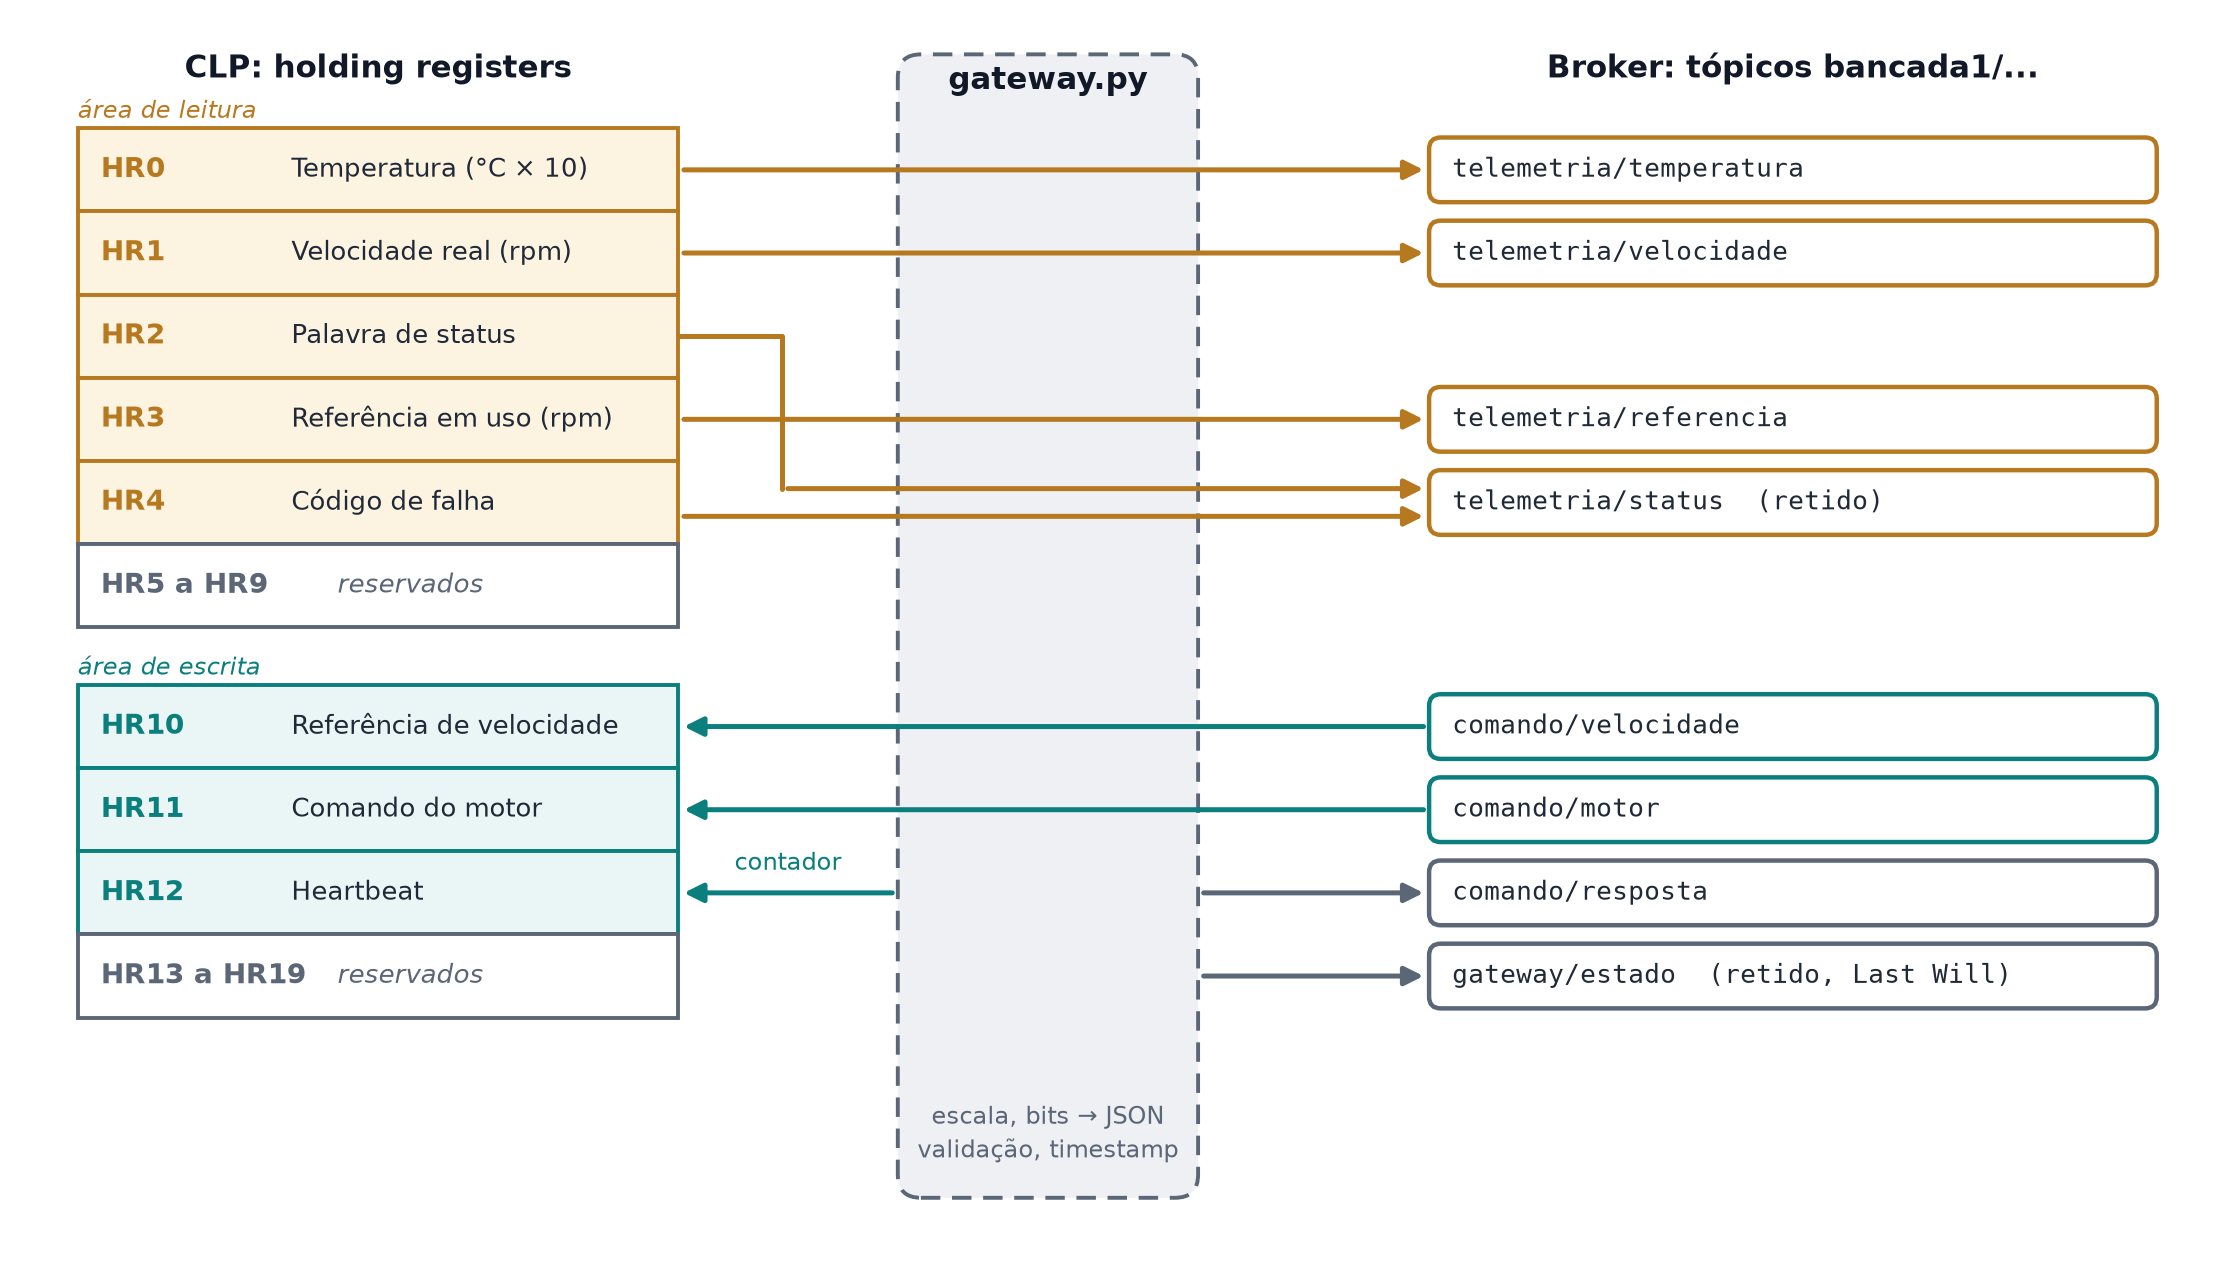

| Registrador | Conteúdo | Quem escreve |
|---|---|---|
| HR0 | Temperatura em °C × 10 (235 = 23,5 °C) | CLP |
| HR1 | Velocidade (rpm) | CLP |
| HR2 | Palavra de status, um bit por informação | CLP |
| HR3 | Referência que o CLP está aplicando (rpm) | CLP |
| HR4 | Código de falha (0 = sem falha) | CLP |
| HR10 | Referência de velocidade pedida (rpm) | gateway |
| HR11 | Comando: 0 parar, 1 ligar, 2 reconhecer falha | gateway |
| HR12 | Heartbeat: contador que o gateway incrementa a cada segundo | gateway |

Por que HR10 e HR3 são diferentes: HR10 é o que foi **pedido**, HR3 é o que o CLP **aceitou**. Se alguém pedir 5000 rpm, o CLP limita a 1700 e o app mostra a diferença.

Por que o heartbeat existe: se o notebook travar com o motor ligado, ninguém mais comanda a planta. O CLP percebe que o HR12 parou de mudar e, depois de 3 s, para o motor sozinho. A segurança fica no CLP, nunca no software acima dele (ADR-005).

### Checkpoint

Na Watch Table, monitore `"DB_HoldingRegisters".holdingRegister[0]` a `[12]`. Segure o termopar com a mão: `[0]` deve subir. Gire a chave local/remoto: o valor de `[2]` deve mudar.

**Plano B:** se o CLP não compilar ou não responder, coloque `MODO=simulado`, `MODBUS_HOST=127.0.0.1` e `MODBUS_PORT=5020` no `config.env` e rode `.venv\Scripts\python clp_simulado.py` num terminal separado. O simulado tem o mesmo mapa e a mesma lógica. Nele, digite `l` + Enter para a chave em local, `r` para remoto, `e` para a emergência.

## Etapa 1: ler o CLP em Python (0:50 a 1:20)

Abra `gateway/gateway.py`. Ele já tem a estrutura pronta; os trechos que você vai escrever estão marcados com `# TODO etapa 1`, `# TODO etapa 3` e assim por diante (a etapa 2 é o broker, em outros arquivos), cada um com uma dica.

Nesta etapa, só a função `ler_clp`. Ela faz o mesmo que o `cliente.js` da Aula 1 fazia em JavaScript: uma requisição **FC 3 (read holding registers)** pedindo os registradores HR0 a HR9 de uma vez.

### O que escrever em `ler_clp`

1. Chame `self.clp.read_holding_registers(c.LEITURA_INICIO, count=c.LEITURA_QUANTIDADE)`. `self.clp` é um `ModbusTcpClient` do pymodbus, já criado e conectado no `__init__` e em `conectar_clp`.
2. Envolva a chamada em `try`/`except Exception`: se o cabo sair ou o CLP não responder, o pymodbus levanta exceção. Nesse caso, registre com `log.warning(...)` e devolva `None`.
3. Se a chamada voltar, confira `resposta.isError()`. Um CLP pode responder com uma **exceção Modbus** (por exemplo, código 02, endereço ilegal). Nesse caso, também devolva `None`.
4. Se deu tudo certo, devolva `resposta.registers`, que é uma lista com 10 inteiros.

Não precisa converter nada: o `ciclo()` já chama `c.decodificar_leitura(registradores)`, que aplica a escala da temperatura e separa os bits do status. Vale abrir `contrato.py` e ler essas funções: é o contrato da seção anterior virando código.

### Rodar

```
.venv\Scripts\python gateway\gateway.py
```

Pare com Ctrl+C.

### Checkpoint

A cada segundo deve aparecer uma linha como:

```
10:32:05 INFO [gateway] T=24.8 °C  v=0 rpm  ref=0 rpm  remoto=True  falha=0
```

Segure o termopar: `T` deve subir. Se aparecer `sem leitura do CLP`, sua `ler_clp` está devolvendo `None`: confira o IP e a porta no `config.env` e se o CLP está em RUN.

### Para pensar

- A temperatura chega como um inteiro de 16 bits. Como o `para_int16` do `contrato.py` transforma 65336 em -200, e por que isso é necessário para temperaturas negativas?
- O gateway lê 10 registradores numa só requisição, em vez de 5 requisições separadas. Olhando o formato do quadro Modbus TCP da Aula 2, o que isso economiza?

## Etapa 2: levantar o broker MQTT (1:20 a 2:00)

O broker é o carteiro do MQTT: recebe cada mensagem publicada e entrega a quem assinou aquele tópico. Na arquitetura, ele é o **conduto** entre a zona OT (CLP e gateway) e a zona TI (banco e app). Cada grupo vai levantar o seu, no próprio notebook, com o **Mosquitto**.

Tudo o que o broker faz vem de dois arquivos de texto que vocês vão escrever: o `broker/mosquitto.conf` (como o broker funciona) e o `broker/acl` (quem pode o quê). Os dois já existem na pasta com lacunas `TODO`.

### Passo 1: o `mosquitto.conf`

Abra `broker/mosquitto.conf` e complete os cinco `TODO`. Cada um vira uma ou duas linhas no formato `opção valor`:

| TODO | Opção | O que faz | Por quê |
|---|---|---|---|
| 1 | `allow_anonymous` | Com `false`, ninguém conecta sem usuário e senha | Sem isso, qualquer um na rede publica comandos para o seu motor |
| 2 | `password_file` e `acl_file` | Dizem onde estão o arquivo de senhas e o de regras | Caminhos relativos à pasta de onde o broker é iniciado: `broker/senhas` e `broker/acl` |
| 3 | `persistence` | Com `false`, o broker não grava nada em disco e começa vazio a cada reinício | Nenhum estado velho sobrevive; o gateway republica o status ao reconectar (ADR-013) |
| 4 | `listener 1883` | Abre a porta MQTT padrão | Por ela conectam o gateway e o middleware |
| 5 | `listener 9001` e, na linha seguinte, `protocol websockets` | Abre uma segunda porta, que fala MQTT dentro de WebSocket | Navegador não abre conexão TCP pura; o app do celular só consegue MQTT sobre WebSocket |

A referência de todas as opções está em https://mosquitto.org/man/mosquitto-conf-5.html.

### Passo 2: a `acl`

Abra `broker/acl`. Cada usuário tem uma linha `user <nome>` e, abaixo, uma linha por permissão:

```
user gateway
topic write bancadaN/telemetria/#
topic read bancadaN/comando/motor
```

`read` deixa **assinar**, `write` deixa **publicar**, e `#` vale para todos os níveis abaixo. Tudo o que não estiver escrito é proibido. Complete os quatro usuários seguindo os comentários, com o número da sua bancada no lugar de `N`:

| Usuário | Quem usa | Pode publicar | Pode assinar |
|---|---|---|---|
| `gateway` | gateway.py | telemetria, resposta de comando, estado do gateway | os dois tópicos de comando |
| `middleware` | middleware.py | nada | tudo da bancada |
| `app_leitura` | app, para qualquer pessoa | nada | telemetria, respostas, estado |
| `operador` | app e MQTT Explorer, para quem comanda | os dois tópicos de comando | o mesmo que o `app_leitura` |

Compare com a tabela de tópicos da etapa 3 (seção 5.6 do `Arquitetura.md`): cada tópico precisa estar liberado para quem publica e para quem assina, e só para eles.

### Passo 3: os usuários e senhas

O `mosquitto_passwd` cria o arquivo de senhas. As senhas não ficam gravadas em texto: ele guarda só um hash. Na pasta do projeto:

```
& "C:\Program Files\mosquitto\mosquitto_passwd.exe" -c -b broker\senhas gateway SENHA_DO_GATEWAY
& "C:\Program Files\mosquitto\mosquitto_passwd.exe" -b broker\senhas middleware SENHA_DO_MIDDLEWARE
& "C:\Program Files\mosquitto\mosquitto_passwd.exe" -b broker\senhas app_leitura leitura
& "C:\Program Files\mosquitto\mosquitto_passwd.exe" -b broker\senhas operador SENHA_DO_OPERADOR
```

O `-c` **cria** o arquivo do zero: use só no primeiro comando, senão apaga os usuários anteriores. O `-b` recebe a senha na própria linha. A senha do `app_leitura` é `leitura` porque ela vai dentro do app, que qualquer um pode abrir (ADR-014): esse usuário só lê.

Coloque as senhas do gateway e do middleware no `config.env` (`MQTT_SENHA_GATEWAY` e `MQTT_SENHA_MIDDLEWARE`).

### Passo 4: subir o broker

Na pasta do projeto:

```
& "C:\Program Files\mosquitto\mosquitto.exe" -c broker\mosquitto.conf -v
```

O `-v` mostra no terminal cada conexão, assinatura e publicação. Deixe essa janela aberta: ela é o log do broker durante a aula.

### Checkpoint

No MQTT Explorer, crie uma conexão para `127.0.0.1`, porta `1883`, e teste:

| Tentativa | Resultado esperado |
|---|---|
| Sem usuário | Recusada (`not authorized`) |
| `operador` com senha errada | Recusada |
| `operador` com a senha certa | Conecta; ainda não há tópicos |

Na janela do broker aparecem as tentativas recusadas e a conexão aceita. Mostre ao monitor.

### Se não funcionar

| Mensagem do Mosquitto | Causa | O que fazer |
|---|---|---|
| `Only one usage of each socket address` | Porta 1883 ocupada, quase sempre pelo serviço do Mosquitto | `Stop-Service mosquitto` como administrador |
| `Unable to open pwfile` ou `Unable to open acl_file` | Caminho errado, ou broker iniciado fora da pasta do projeto | Rode o comando dentro da pasta `projeto_aluno` |
| `Error: Unknown configuration variable` | Opção escrita errada | Confira a grafia na tabela do passo 1 |
| Conecta sem senha | `allow_anonymous` não está como `false` | Corrija e reinicie o broker (Ctrl+C e o mesmo comando) |

**Plano B:** se o broker do grupo não subir em 15 minutos, use o broker do monitor: no `config.env`, `BROKER_LOCAL=nao`, `MQTT_HOST=<ip do monitor>` e as credenciais `gateway_bancadaN` e `middleware_bancadaN` que o monitor entregar.

### Para pensar

- Por que o gateway e o celular usam portas diferentes do mesmo broker?
- Olhando a sua `acl`: o que o `app_leitura` consegue fazer se alguém descobrir a senha dele, e o que ele não consegue?

## Etapa 3: publicar no broker (2:10 a 2:45)

Agora os dados saem do seu notebook e vão para o broker, onde qualquer programa autorizado pode assinar.

### Conceitos que aparecem no código

| Conceito | No projeto |
|---|---|
| **Tópico** | Endereço da mensagem, hierárquico: `bancada3/telemetria/temperatura` |
| **Publicar / assinar** | O gateway publica; quem quer o dado assina o tópico, sem conhecer o gateway |
| **QoS 0** | Entrega no máximo uma vez. Usado na telemetria: perder uma amostra por segundo não faz diferença |
| **QoS 1** | Entrega pelo menos uma vez, com confirmação. Usado em status e comandos |
| **Mensagem retida** | O broker guarda a última e entrega a quem assinar depois. Usado no status, para o app abrir já sabendo o estado da planta |
| **Last Will** | Mensagem que o broker publica sozinho se o gateway cair sem avisar. Usado para o app mostrar "gateway desconectado" |

### O que escrever

**`conectar_broker`**: criar e conectar o cliente MQTT.

1. `cliente = mqtt.Client(mqtt.CallbackAPIVersion.VERSION2, client_id=f"gateway-{self.bancada}")`
2. `cliente.username_pw_set(...)` com usuário e senha do `self.cfg`.
3. `cliente.will_set(self.t["estado"], json.dumps({"estado": "offline"}), qos=1, retain=True)`: a Last Will. Tem que ser configurada **antes** de conectar.
4. Ligue os callbacks: `cliente.on_connect = self.ao_conectar` e `cliente.on_message = self.ao_receber`.
5. `cliente.reconnect_delay_set(1, 30)`: se o broker cair, tenta de novo entre 1 e 30 s.
6. `cliente.connect_async(host, porta, keepalive=10)` e `cliente.loop_start()`. O `loop_start` cria uma thread só para a rede MQTT, enquanto o laço principal continua lendo o CLP.
7. Guarde em `self.mqtt = cliente`.

**`publicar`**: `self.mqtt.publish(topico, json.dumps(dados, ensure_ascii=False), qos=qos, retain=retain)`, se `self.mqtt` não for `None`.

**`publicar_telemetria`**: três chamadas a `self.publicar`, uma para cada grandeza, no formato do contrato:

```json
{ "valor": 23.5, "unidade": "°C", "ts": "2026-10-01T14:32:05.120Z" }
```

Os tópicos estão em `self.t` (por exemplo `self.t["temperatura"]`). O `ts` já vem pronto como parâmetro: é o horário da leitura, gerado pelo gateway (ADR-023).

### Checkpoint

Com o broker da etapa 2 rodando, rode o gateway de novo. No MQTT Explorer, conectado como `operador`, a sua `bancadaN` deve aparecer com `telemetria/temperatura`, `velocidade`, `referencia`, `status` e `gateway/estado`.

Na janela do broker, observe a conexão do usuário `gateway` e cada publicação chegando.

Pare o gateway com Ctrl+C e observe `gateway/estado` mudar para `offline`. Agora feche a janela do terminal em vez de usar Ctrl+C: depois de alguns segundos o broker publica `offline` sozinho. Isso é a Last Will.

### Para pensar

- Por que o status é publicado só quando muda, e a temperatura a cada segundo?
- Tire da `acl` a linha `topic write bancadaN/telemetria/#` do gateway e reinicie o broker. O que acontece com os tópicos no MQTT Explorer? (Depois devolva a linha.)

## Etapa 4: comandar o motor (2:45 a 3:30)

Agora o caminho inverso: uma mensagem no broker vira uma escrita no CLP.

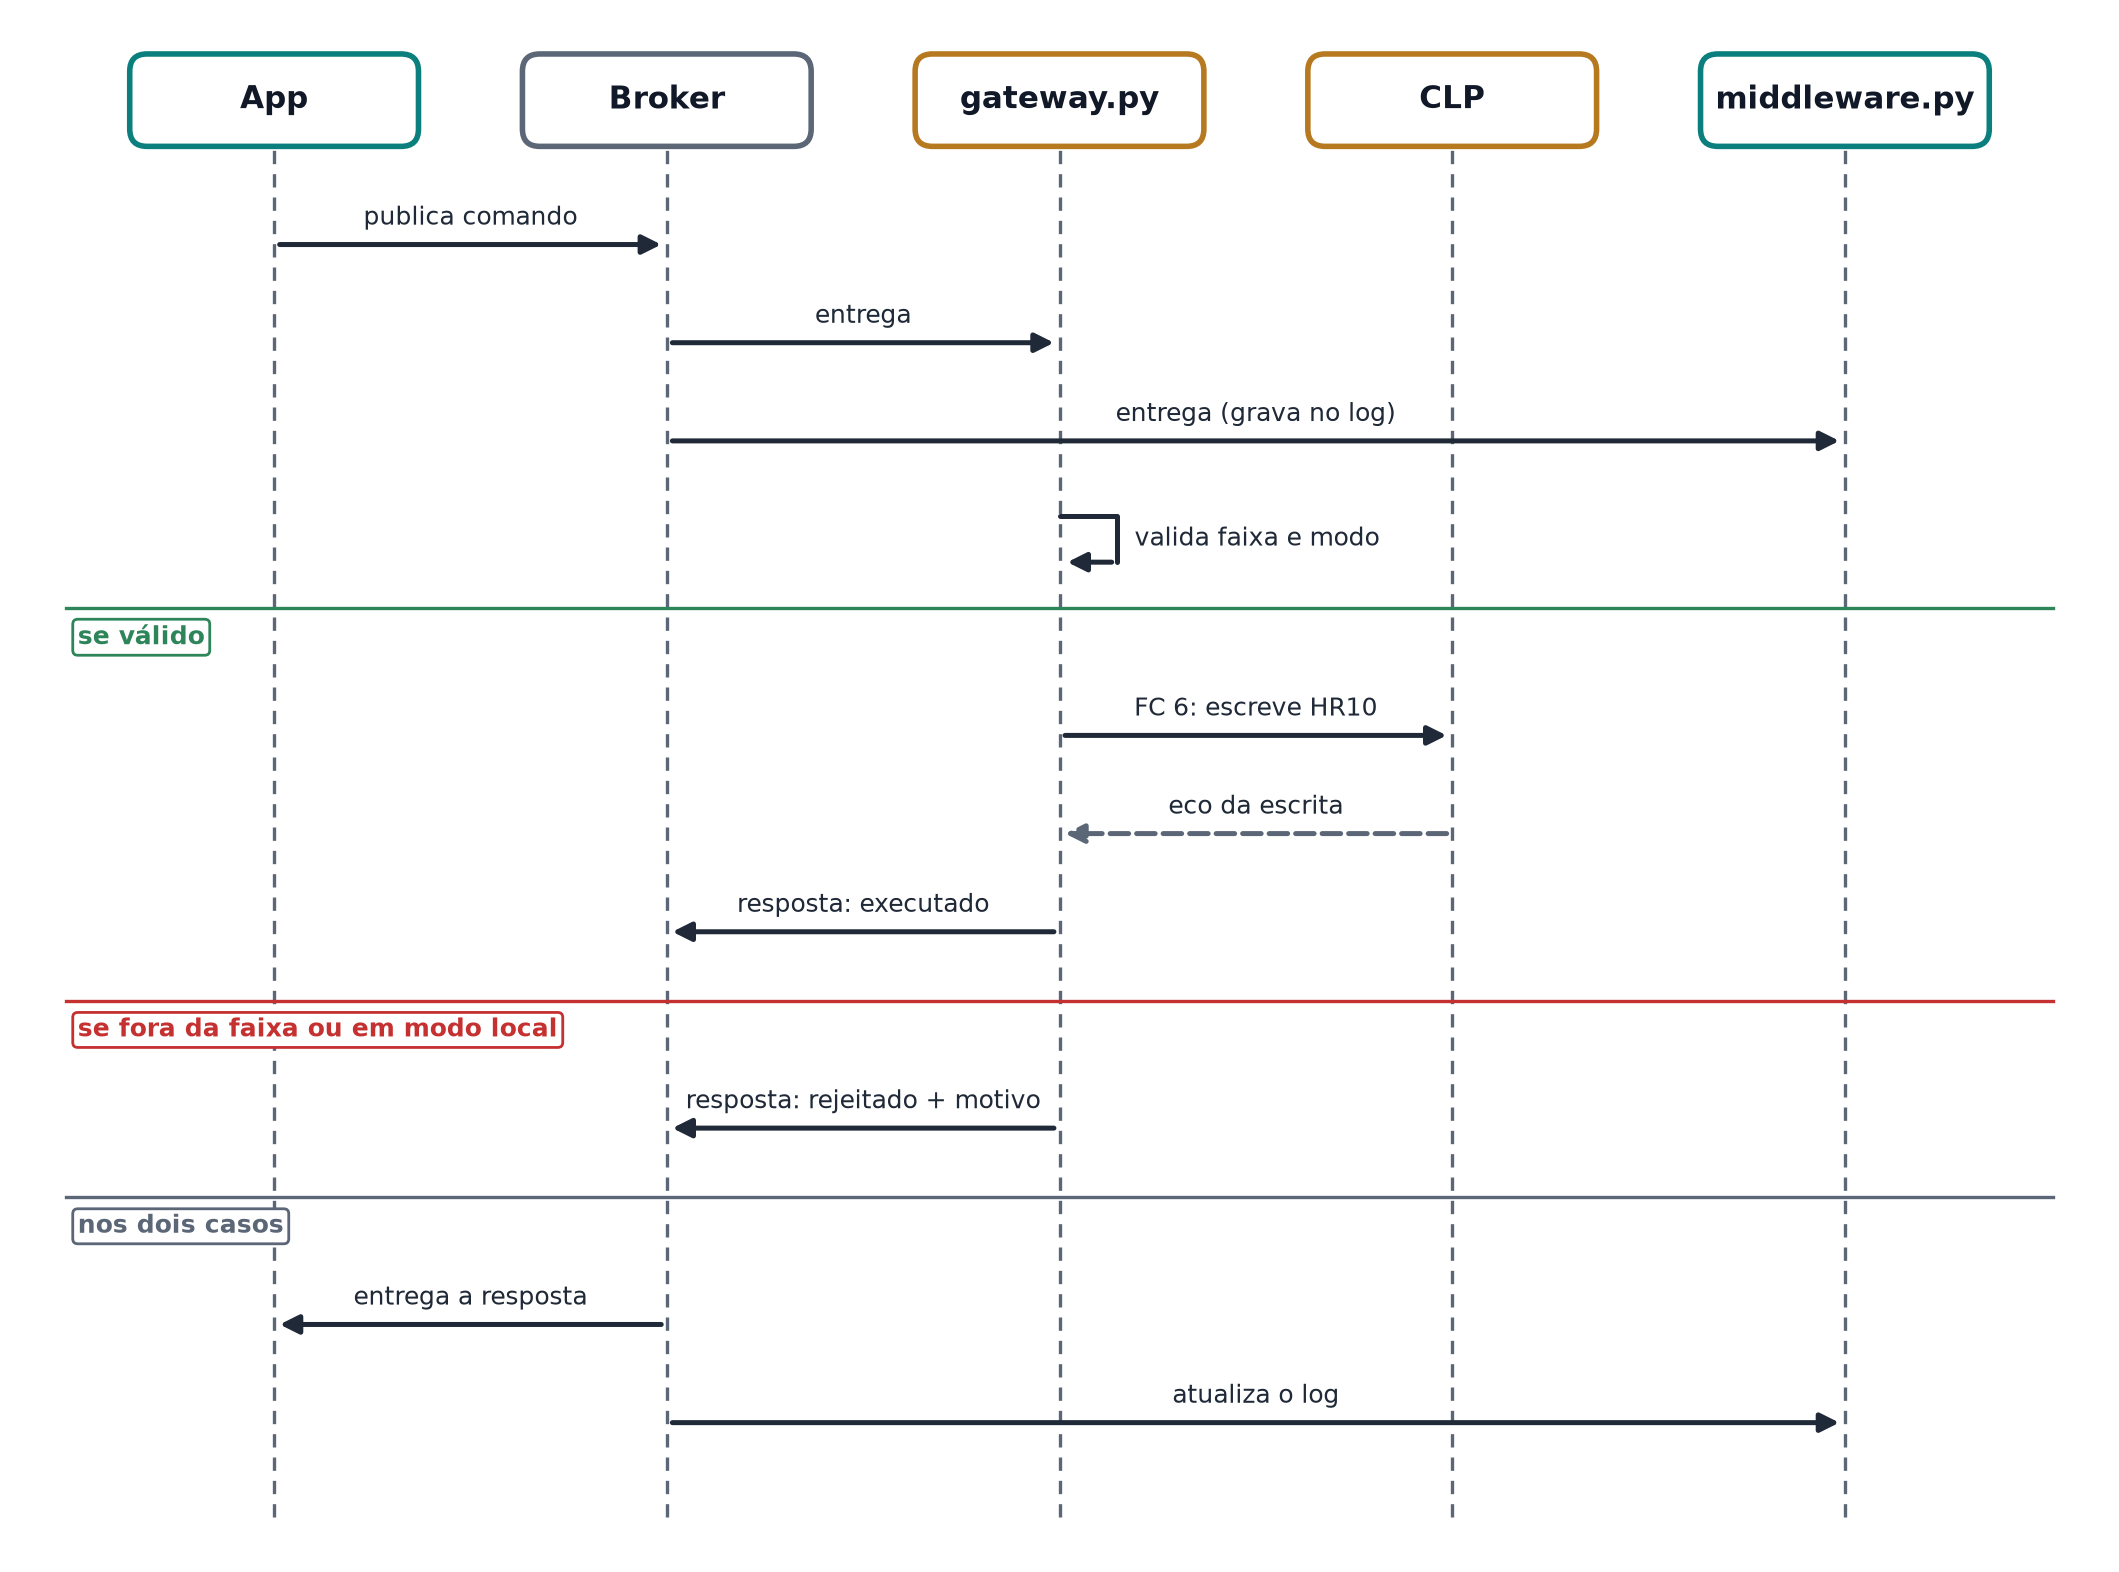

### Por que existe uma fila

O `ao_receber` roda na **thread do MQTT**, a qualquer momento. O laço principal, na outra thread, está lendo o CLP a cada segundo. Se as duas threads usassem a conexão Modbus ao mesmo tempo, as requisições se misturariam no mesmo socket. Por isso o `ao_receber` **só coloca o comando numa fila**, e quem escreve no CLP é sempre o laço principal (ADR-009).

### O que escrever

**`ao_conectar`**: assinar os dois tópicos de comando com QoS 1:
`cliente.subscribe([(self.t["cmd_velocidade"], 1), (self.t["cmd_motor"], 1)])`.
Fica aqui, e não no `conectar_broker`, porque o `on_connect` roda de novo a cada reconexão.

**`ao_receber`**: descobrir o tipo pelo tópico (`"velocidade"` se for `self.t["cmd_velocidade"]`, senão `"motor"`) e fazer `self.fila.put((time.monotonic(), tipo, mensagem.payload))`. O horário de chegada serve para descartar comando velho (mais de 3 s na fila).

**`escrever_clp`**: FC 6 com `self.clp.write_register(endereco, valor)`. Devolva `None` se deu certo; `"sem resposta do CLP"` se levantar exceção; `f"excecao Modbus {resposta.exception_code}"` se `resposta.isError()`.

**`enviar_heartbeat`**: `self.heartbeat = (self.heartbeat + 1) % 65536` e `self.escrever_clp(c.HR_HEARTBEAT, self.heartbeat)`. Sem isso o CLP nunca deixa o motor ligar.

**`validar_comando`** (no topo do arquivo): a validação da ADR-011, parando na primeira falha:

| Passo | Condição | Se falhar |
|---|---|---|
| 1 | `json.loads(carga)` funciona, tem `"id"` (texto não vazio) e `"valor"` (número, e não `bool`) | `Rejeitado("formato invalido", id)` (sem `id` se ele não existir) |
| 2 | velocidade: `0 <= valor <= vel_max`; motor: `valor` em `c.COMANDOS_MOTOR` | `"fora da faixa"` ou `"valor invalido"` |
| 3 | `status` não é `None` e `status["modo_remoto"]` é verdadeiro | `"estado do CLP desconhecido"` ou `"modo local"` |

Se passar, devolva `Comando(id, c.HR_CMD_VELOCIDADE, round(valor))` ou `Comando(id, c.HR_CMD_MOTOR, int(valor))`.

O `executar` e o `responder`, que já estão prontos, usam a sua `validar_comando` e publicam a resposta em `bancadaN/comando/resposta`.

### Checkpoint

Com o gateway rodando, no MQTT Explorer (usuário `operador`), publique em `bancadaN/comando/velocidade`:

```json
{"id": "t1", "valor": 600}
```

e depois, **com o monitor olhando a bancada**, em `bancadaN/comando/motor`:

```json
{"id": "t2", "valor": 1}
```

O motor deve partir e chegar a 600 rpm. Em `comando/resposta` aparecem as respostas com `"resultado": "executado"`. Agora tente:

| Publicar | Resposta esperada |
|---|---|
| `{"id": "t3", "valor": 9000}` em `velocidade` | `rejeitado`, `fora da faixa` |
| `{"id": "t4", "valor": 7}` em `motor` | `rejeitado`, `valor invalido` |
| chave em local e `{"id": "t5", "valor": 1}` em `motor` | `rejeitado`, `modo local` |
| `{"id": "t6", "valor": 0}` em `motor` | `executado`, motor para |

### Para pensar

- Por que um comando **nunca** é publicado como mensagem retida? Pense no que aconteceria quando o gateway reiniciasse.
- O gateway rejeita velocidade acima de 1700, e o CLP também limita. Por que a regra existe nos dois lugares?

## Etapa 5: banco e app (3:30 a 4:05)

O middleware assina **todos** os tópicos da sua bancada, grava no SQLite e serve o app. Ele nunca fala com o CLP.

Abra `middleware/middleware.py`. São dois trechos:

**`tratar(topico, dados)`**: o tópico chega como `bancadaN/<tipo>/<nome>` e já vem separado em `tipo` e `nome`.

| Mensagem | O que fazer |
|---|---|
| `tipo == "telemetria"` e `nome` em `GRANDEZAS` | `self.banco.gravar_medicao(dados["ts"], nome, dados["valor"], dados.get("unidade"))` |
| `tipo == "comando"` e `nome` é `"velocidade"` ou `"motor"` | `self.banco.gravar_comando(dados["id"], topico, dados.get("valor"))` |
| `tipo == "comando"` e `nome == "resposta"` | `self.banco.gravar_resposta(dados["id"], dados["resultado"], dados.get("motivo", ""), dados["ts"])` |

**`historico(grandeza, horas)`**: a consulta SQL que alimenta o gráfico do app:

```sql
SELECT ts, valor, unidade FROM medicoes WHERE grandeza = ? AND ts >= ? ORDER BY ts
```

com os parâmetros `(grandeza, corte)`, devolvendo `[dict(linha) for linha in linhas]`. Os `?` são preenchidos pelo SQLite: nunca monte SQL juntando texto com `+` ou f-string, porque isso abre espaço para injeção de SQL.

### Rodar tudo junto

Pare o gateway **e o broker** (Ctrl+C nas duas janelas) e rode:

```
.\iniciar.ps1
```

Ele abre uma janela para o broker, uma para o middleware e uma para o gateway, e mostra o endereço do app. Se o Windows perguntar se o Python ou o Mosquitto podem acessar a rede, clique em **Permitir** (rede privada).

### Checkpoint

1. No navegador do notebook, abra `http://127.0.0.1:8000`: a sua bancada aparece com os valores ao vivo e o gráfico.
2. No **celular**, conectado ao Wi-Fi do laboratório, abra o endereço que o `iniciar.ps1` mostrou.
3. No app, entre com `operador`, mude a referência e ligue o motor (com o monitor olhando).
4. Abra `http://127.0.0.1:8000/docs`: é a documentação automática da API, gerada pelo FastAPI.

### Para pensar

- O celular recebe os valores ao vivo direto do broker, pela porta 9001 (MQTT sobre WebSocket), e o histórico pelo middleware, por HTTP. Por que dois caminhos?
- A senha do `app_leitura` está escrita no código do app. Isso é um problema? Veja a ADR-014.

## Etapa 6: segurança (4:10 a 4:40)

As decisões de segurança do projeto estão nas ADRs 005, 014, 015 e 029. Agora elas vão ser vistas funcionando, e falhando onde foram aceitas como risco.

### 6.1 Watchdog (o monitor faz, os grupos observam)

Com o motor da bancada ligado pelo app, o monitor fecha a janela do gateway. Observe:
- o motor para em até 3 s;
- o app mostra "gateway desconectado" (Last Will);
- o status mostra `heartbeat perdido` e falha 2.

Religue o gateway: o motor **não** volta a girar sozinho. É preciso reconhecer a falha e ligar de novo. Por que isso é o comportamento certo?

### 6.2 Modo local

Coloque a chave da bancada em local e tente ligar pelo app. O comando volta `rejeitado` (`modo local`). Em máquina real, é o que impede alguém de ligar remotamente um motor em que outra pessoa está mexendo.

### 6.3 A ACL que vocês escreveram

No MQTT Explorer, conecte com o usuário `app_leitura` (senha `leitura`) e publique em `bancadaN/comando/motor`:

```json
{"id": "invasor", "valor": 1}
```

O motor não liga e nenhuma resposta aparece em `comando/resposta`. Na janela do broker aparece a publicação negada. O broker descartou a mensagem porque a **sua** `acl` não dá `write` ao `app_leitura`. Repare que quem publicou não recebe erro nenhum: o broker descarta em silêncio.

Agora conecte como `app_leitura` e tente publicar em `bancadaN/telemetria/temperatura` o valor `{"valor": 999, "ts": "x"}`. O 999 não aparece no app: sem a ACL, qualquer um falsificaria a temperatura.

### 6.4 A senha trafega aberta

O gateway fala com o broker dentro do próprio notebook (127.0.0.1), então a captura é na interface de loopback.

1. Abra o Wireshark e escolha a interface **Adapter for loopback traffic capture**.
2. Filtro: `mqtt`.
3. Reinicie o gateway (Ctrl+C e rode de novo).
4. Encontre o pacote **Connect Command**, abra **MQ Telemetry Transport Protocol** e veja os campos **User Name** e **Password**.

A senha do gateway está em texto claro. O mesmo vale para o celular: capturando na interface do Wi-Fi com o filtro `tcp.port == 9001`, a senha do `operador` digitada no app também passa aberta. Isso foi uma decisão consciente para a monitoria (ADR-015): com TLS, cada celular teria que aceitar um certificado autoassinado. Numa fábrica, isso seria inaceitável: a porta seria 8883 com TLS.

### Discussão

A ADR-029 define o alvo de segurança do projeto como **SL 1** da IEC 62443: proteção contra erro e curiosidade, não contra ataque intencional. Olhando o que vocês fizeram em 6.3 e 6.4, o que seria preciso para chegar a SL 2?

## Fechamento e entregável (4:40 a 5:00)

Cada grupo entrega:

1. O arquivo `bancadaN_medicoes.csv`, baixado pelo link **Baixar medições (CSV)** do app (ou `http://127.0.0.1:8000/exportar.csv`).
2. Um print do app no celular com o motor ligado.
3. Respostas curtas:
   - Em qual nível do modelo Purdue fica cada peça que vocês construíram (CLP, gateway, broker, middleware, app)?
   - Qual caminho uma mensagem de comando percorre, do toque no celular até o motor, passando por quais protocolos?
   - Cite um risco que o projeto aceitou e o que seria preciso para eliminá-lo.

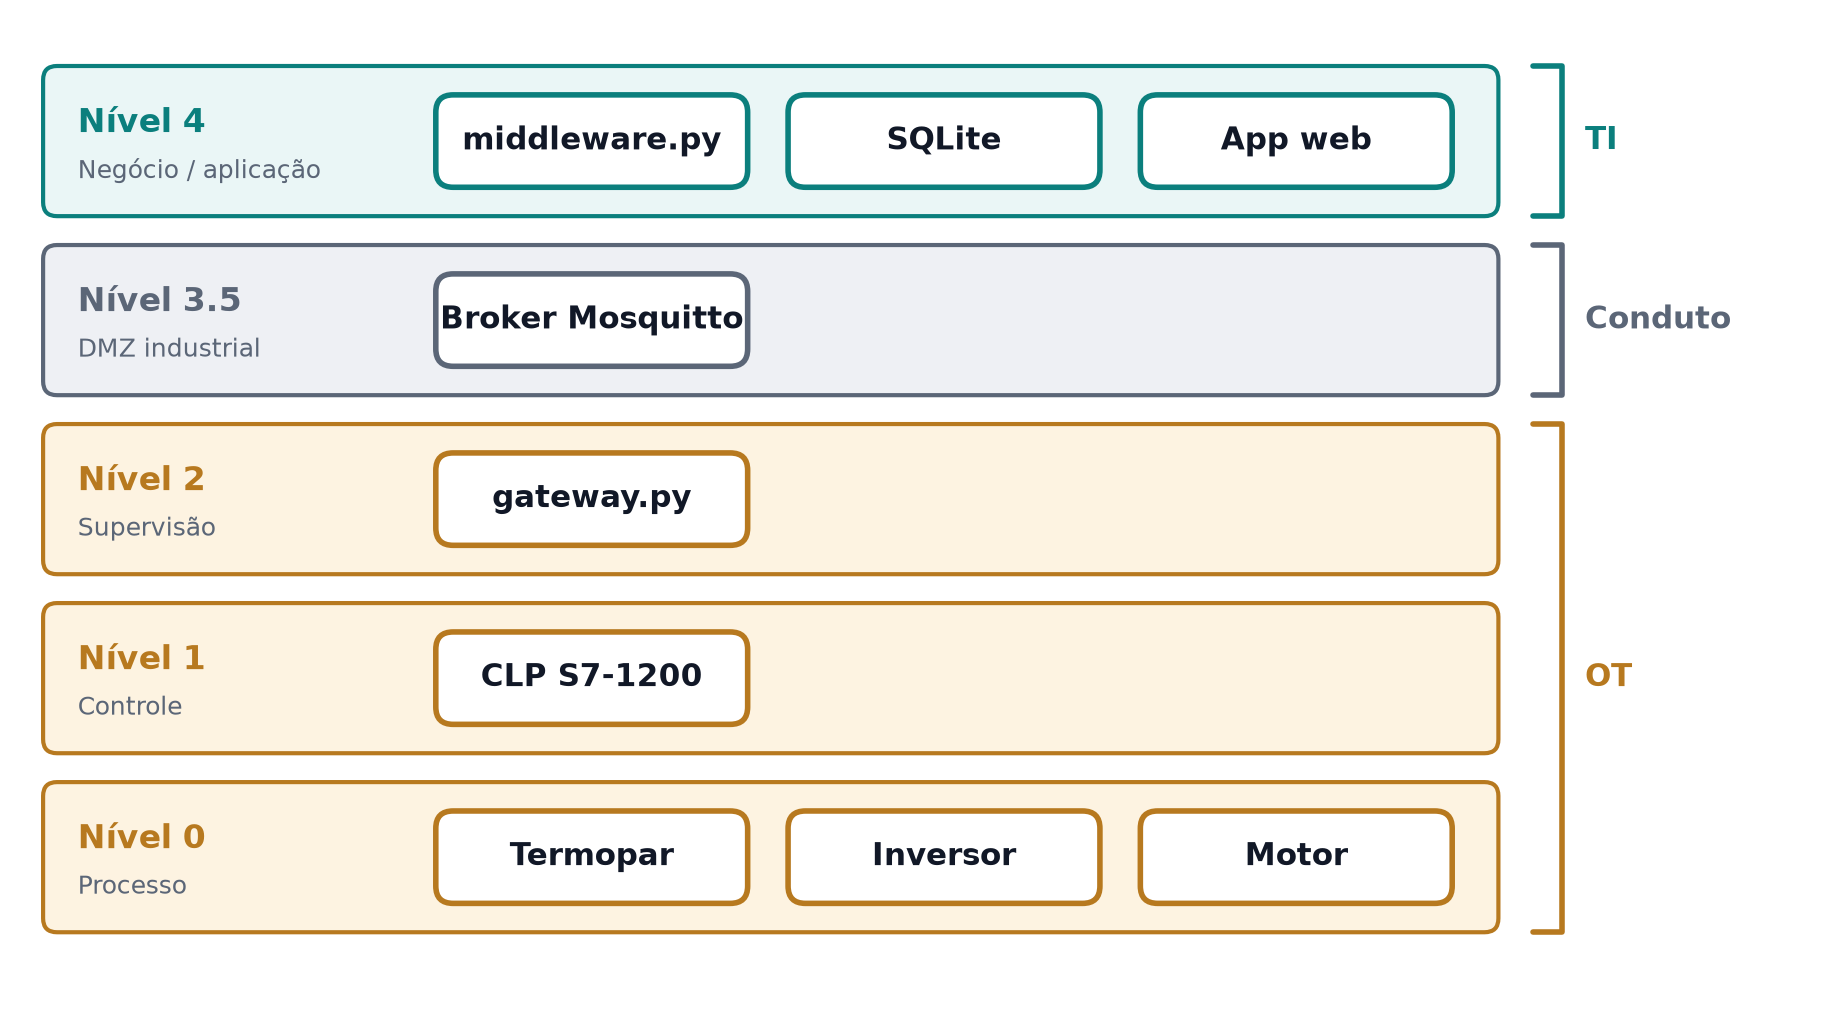

## Quando algo não funciona

| Sintoma | Causa provável | O que fazer |
|---|---|---|
| `Configuração incompleta em config.env` | Chave faltando ou `config.env` não criado | Copie `config.exemplo.env` e preencha todas as chaves |
| `CLP indisponível em ...` | IP errado, cabo, CLP em STOP | `ping` no IP do CLP; confira no TIA Portal se está em RUN |
| `sem leitura do CLP` a cada 5 s | `ler_clp` devolvendo `None` | Veja a mensagem de aviso logo acima; confira o `try`/`except` e o `isError()` |
| `broker recusou a conexão: Not authorized` | Usuário ou senha do `config.env` diferentes dos criados com `mosquitto_passwd` | Confira as senhas; se preciso, recrie o usuário com `mosquitto_passwd -b` |
| Nada aparece no MQTT Explorer | Broker parado, ou a ACL não libera o tópico | Veja a janela do broker: ela mostra conexões e publicações negadas |
| Mosquitto não sobe: `Only one usage of each socket address` | Porta 1883 ocupada pelo serviço do Mosquitto | `Stop-Service mosquitto` como administrador |
| Comando volta `rejeitado`, `modo local` | Chave da bancada em local | Gire para remoto |
| Comando volta `executado` mas o motor não liga | Falha travada ou falta de heartbeat | Veja o código de falha no app; use **Reconhecer falha**; confira a `enviar_heartbeat` |
| Motor para sozinho depois de uns segundos | Heartbeat não está sendo escrito | Confira `enviar_heartbeat` e se ela é chamada no `ciclo` |
| App abre no notebook mas não no celular | Firewall do Windows bloqueando a porta 8000 | Permita o Python em redes privadas, ou peça ajuda ao monitor |
| App abre mas os valores ficam em `--` | Celular não alcança o broker na porta 9001 | Confira se o celular está no Wi-Fi do laboratório |
| Gráfico vazio | `historico` devolvendo `[]` | Confira a consulta SQL da etapa 4 |